# pyscdrs vs scDRS — reference comparison

This notebook validates **pyscdrs** (the omicverse pure-Python
reimplementation of scDRS) against the original `scdrs` package on
scDRS's own bundled toy data (`toydata_mouse`).

We compare:

1. `preprocess` — gene-level statistics and mean-variance bins.
2. `score_cell` — raw / normalized disease scores and p-values.
3. Downstream group-level analysis.
4. A UMAP embedding coloured by the disease score.
5. Timing.

With the same `random_seed` the two implementations should agree to
within floating-point tolerance (here: bit-exact).

In [1]:
import os, time, warnings
warnings.filterwarnings('ignore')
%matplotlib inline
import numpy as np
import pandas as pd
import anndata
import scanpy as sc
import matplotlib.pyplot as plt

import pyscdrs
import scdrs  # reference package

print('pyscdrs', pyscdrs.__version__)
print('scdrs (reference)', scdrs.__version__ if hasattr(scdrs, '__version__') else 'n/a')

pyscdrs 0.1.0
scdrs (reference) 1.0.2


## 1. Load the toy data

scDRS ships a 30-cell x 2500-gene mouse toy dataset and a
matching `.gs` gene set; we use that exact data.

In [2]:
DATA = os.path.join('..', 'tests')
adata = anndata.read_h5ad(os.path.join(DATA, 'toydata_mouse.h5ad'))
df_cov = pd.read_csv(os.path.join(DATA, 'toydata_mouse.cov'), sep='\t', index_col=0)
dict_gs = pyscdrs.load_gs(os.path.join(DATA, 'toydata_mouse.gs'))
genes, weights = dict_gs['toydata_gs_mouse']
print('adata:', adata.shape, '| disease genes:', len(genes))
adata.obs[['cell_type', 'covariate']].head()

adata: (30, 2500) | disease genes: 250


,cell_type,covariate
index,,
N1.MAA000586.3_8_M.1.1-1-1,causal_cell,10
F10.D041911.3_8_M.1.1-1-1,causal_cell,10
A17_B002755_B007347_S17.mm10-plus-7-0,causal_cell,10
C22_B003856_S298_L004.mus-2-0-1,causal_cell,10
G12.B002765.3_38_F.1.1-1-1,causal_cell,10


## 2. Preprocess with both packages

Covariate-corrected gene statistics and mean-variance bins.

In [3]:
a_mine = adata.copy()
a_ref  = adata.copy()

t0 = time.perf_counter(); pyscdrs.preprocess(a_mine, cov=df_cov)
t_pp_mine = time.perf_counter() - t0
t0 = time.perf_counter(); scdrs.pp.preprocess(a_ref, cov=df_cov)
t_pp_ref = time.perf_counter() - t0

gs_mine = a_mine.uns['SCDRS_PARAM']['GENE_STATS']
gs_ref  = a_ref.uns['SCDRS_PARAM']['GENE_STATS']
print(f'preprocess time: pyscdrs {t_pp_mine:.3f}s | scdrs {t_pp_ref:.3f}s')
for col in ['mean', 'var', 'var_tech', 'ct_mean', 'ct_var']:
    md = np.abs(gs_mine[col].astype(float).values - gs_ref[col].astype(float).values).max()
    print(f'  GENE_STATS[{col:9s}]  max|diff| = {md:.3e}')
print('  mean_var bins identical:', bool((gs_mine['mean_var'] == gs_ref['mean_var']).all()))

Too few genes for 20*20 bins, setting n_mean_bin=n_var_bin=15


Too few genes for 20*20 bins, setting n_mean_bin=n_var_bin=15


preprocess time: pyscdrs 0.051s | scdrs 0.198s
  GENE_STATS[mean     ]  max|diff| = 0.000e+00
  GENE_STATS[var      ]  max|diff| = 0.000e+00
  GENE_STATS[var_tech ]  max|diff| = 0.000e+00
  GENE_STATS[ct_mean  ]  max|diff| = 0.000e+00
  GENE_STATS[ct_var   ]  max|diff| = 0.000e+00
  mean_var bins identical: True


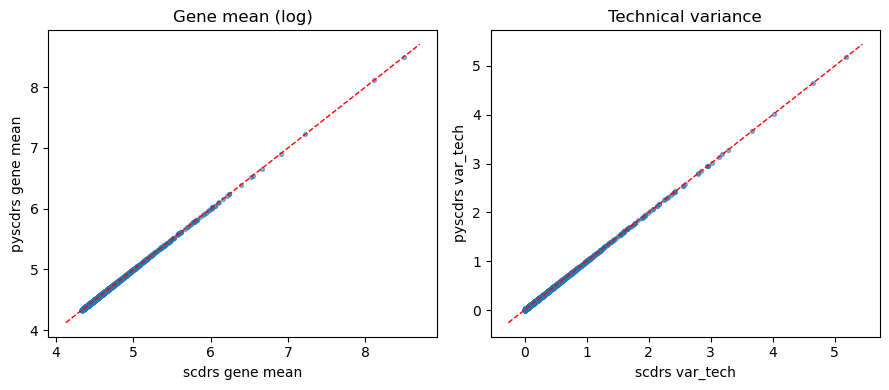

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].scatter(gs_ref['mean'].astype(float), gs_mine['mean'].astype(float), s=8, alpha=0.5)
axes[0].set(xlabel='scdrs gene mean', ylabel='pyscdrs gene mean', title='Gene mean (log)')
axes[1].scatter(gs_ref['var_tech'].astype(float), gs_mine['var_tech'].astype(float), s=8, alpha=0.5)
axes[1].set(xlabel='scdrs var_tech', ylabel='pyscdrs var_tech', title='Technical variance')
for ax in axes:
    lim = ax.get_xlim(); ax.plot(lim, lim, 'r--', lw=1)
plt.tight_layout(); plt.show()

## 3. Score cells

`score_cell` with `n_ctrl=1000` and `random_seed=0` for both.

In [5]:
t0 = time.perf_counter()
r_mine = pyscdrs.score_cell(a_mine, genes, gene_weight=weights,
                            n_ctrl=1000, random_seed=0,
                            return_ctrl_norm_score=True)
t_sc_mine = time.perf_counter() - t0

t0 = time.perf_counter()
r_ref = scdrs.score_cell(a_ref, genes, gene_weight=weights,
                         n_ctrl=1000, random_seed=0,
                         return_ctrl_norm_score=True)
t_sc_ref = time.perf_counter() - t0

print(f'score_cell time: pyscdrs {t_sc_mine:.3f}s | scdrs {t_sc_ref:.3f}s')
r_mine[['raw_score', 'norm_score', 'pval', 'mc_pval', 'zscore']].head()

Computing control scores:   0%|                                                                                     | 0/1000 [00:00<?, ?it/s]

Computing control scores:   4%|██▋                                                                        | 36/1000 [00:00<00:02, 353.14it/s]

Computing control scores:   7%|█████▍                                                                     | 72/1000 [00:00<00:02, 352.86it/s]

Computing control scores:  11%|███████▉                                                                  | 108/1000 [00:00<00:02, 342.81it/s]

Computing control scores:  14%|██████████▋                                                               | 144/1000 [00:00<00:02, 347.45it/s]

...

Computing control scores:  94%|█████████████████████████████████████████████████████████████████████▍    | 938/1000 [00:02<00:00, 358.67it/s]

Computing control scores:  98%|████████████████████████████████████████████████████████████████████████▏ | 975/1000 [00:02<00:00, 360.21it/s]

Computing control scores: 100%|█████████████████████████████████████████████████████████████████████████| 1000/1000 [00:02<00:00, 355.30it/s]

score_cell time: pyscdrs 4.942s | scdrs 4.866s


,raw_score,norm_score,pval,mc_pval,zscore
index,,,,,
N1.MAA000586.3_8_M.1.1-1-1,4.741197,5.179805,0.000033,0.000999,3.987887
F10.D041911.3_8_M.1.1-1-1,4.739066,4.669348,0.000033,0.000999,3.987887
A17_B002755_B007347_S17.mm10-plus-7-0,4.636626,4.486836,0.000033,0.000999,3.987887
C22_B003856_S298_L004.mus-2-0-1,4.680566,5.557366,0.000033,0.000999,3.987887
G12.B002765.3_38_F.1.1-1-1,4.640043,5.798009,0.000033,0.000999,3.987887


In [6]:
summary = {}
for col in ['raw_score', 'norm_score', 'pval', 'mc_pval', 'zscore']:
    r = np.corrcoef(r_mine[col].values, r_ref[col].values)[0, 1]
    md = float(np.abs(r_mine[col].values - r_ref[col].values).max())
    summary[col] = (r, md)
    print(f'  {col:12s} Pearson r = {r:.6f}   max|diff| = {md:.3e}')

  raw_score    Pearson r = 1.000000   max|diff| = 0.000e+00
  norm_score   Pearson r = 1.000000   max|diff| = 0.000e+00
  pval         Pearson r = 1.000000   max|diff| = 0.000e+00
  mc_pval      Pearson r = 1.000000   max|diff| = 0.000e+00
  zscore       Pearson r = 1.000000   max|diff| = 0.000e+00


### Score scatter: pyscdrs vs scDRS

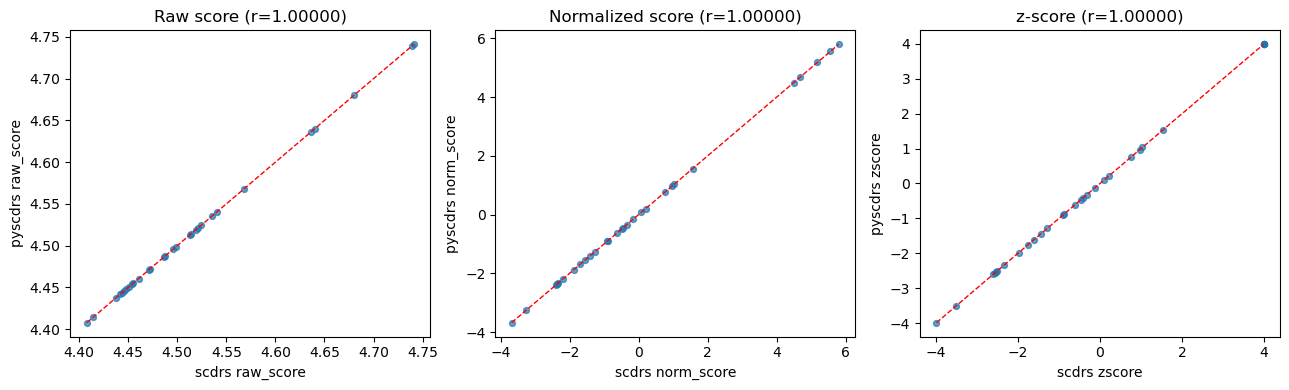

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, ttl in zip(axes,
                        ['raw_score', 'norm_score', 'zscore'],
                        ['Raw score', 'Normalized score', 'z-score']):
    ax.scatter(r_ref[col], r_mine[col], s=18, alpha=0.7)
    lim = [min(r_ref[col].min(), r_mine[col].min()),
           max(r_ref[col].max(), r_mine[col].max())]
    ax.plot(lim, lim, 'r--', lw=1)
    r = summary[col][0] if col in summary else np.nan
    ax.set(xlabel=f'scdrs {col}', ylabel=f'pyscdrs {col}',
           title=f'{ttl} (r={r:.5f})')
plt.tight_layout(); plt.show()

### P-value agreement

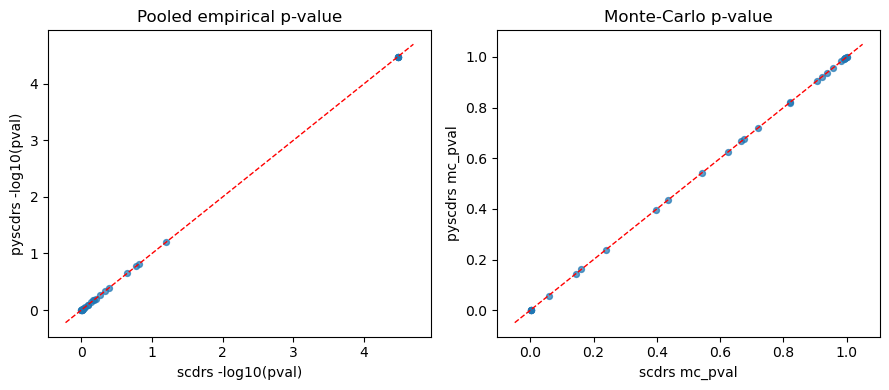

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].scatter(-np.log10(r_ref['pval']), -np.log10(r_mine['pval']), s=18, alpha=0.7)
axes[0].set(xlabel='scdrs -log10(pval)', ylabel='pyscdrs -log10(pval)',
            title='Pooled empirical p-value')
axes[1].scatter(r_ref['mc_pval'], r_mine['mc_pval'], s=18, alpha=0.7)
axes[1].set(xlabel='scdrs mc_pval', ylabel='pyscdrs mc_pval',
            title='Monte-Carlo p-value')
for ax in axes:
    lim = ax.get_xlim(); ax.plot(lim, lim, 'r--', lw=1)
plt.tight_layout(); plt.show()

## 4. Downstream group-level analysis

Cell-group trait association + heterogeneity (Geary's C).

In [9]:
sc.pp.neighbors(a_mine, n_neighbors=15, n_pcs=20)
a_ref.obsp = a_mine.obsp
a_ref.uns['neighbors'] = a_mine.uns.get('neighbors', {})

g_mine = pyscdrs.downstream_group_analysis(a_mine, r_mine, group_cols=['cell_type'])['cell_type']
g_ref  = scdrs.method.downstream_group_analysis(a_ref, r_ref, group_cols=['cell_type'])['cell_type']
print('pyscdrs group analysis:')
display(g_mine[['n_cell', 'assoc_mcp', 'assoc_mcz', 'hetero_mcp', 'hetero_mcz']])
for col in ['assoc_mcp', 'assoc_mcz', 'hetero_mcp', 'hetero_mcz']:
    md = np.abs(g_mine[col].astype(float).values - g_ref[col].astype(float).values).max()
    print(f'  {col:12s} max|diff| vs scdrs = {md:.3e}')

pyscdrs group analysis:


,n_cell,assoc_mcp,assoc_mcz,hetero_mcp,hetero_mcz
group,,,,,
causal_cell,10.0,0.000999,8.727126,0.414585,0.114673
non_causal_cell,20.0,0.923077,-1.330740,0.266733,0.641490


  assoc_mcp    max|diff| vs scdrs = 0.000e+00
  assoc_mcz    max|diff| vs scdrs = 0.000e+00
  hetero_mcp   max|diff| vs scdrs = 0.000e+00
  hetero_mcz   max|diff| vs scdrs = 0.000e+00


## 5. UMAP coloured by the disease score

The toy data has two cell types — `causal_cell` (carrying
the simulated disease signal) and a background type. The
pyscdrs normalized score should be higher in the causal cells.

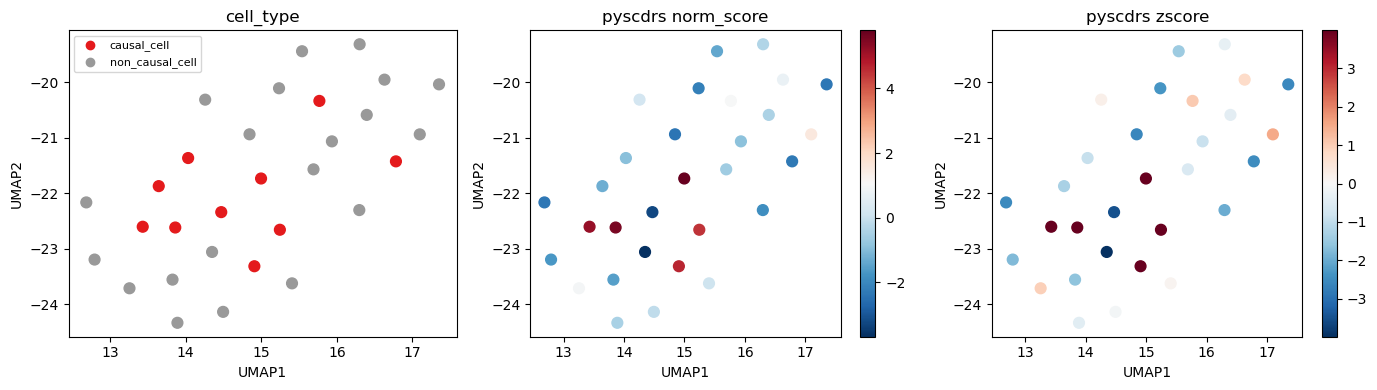

In [10]:
sc.tl.umap(a_mine)
a_mine.obs['scdrs_norm_score'] = r_mine['norm_score'].values
a_mine.obs['scdrs_zscore'] = r_mine['zscore'].values

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
umap = a_mine.obsm['X_umap']
ct_codes = a_mine.obs['cell_type'].astype('category').cat.codes
sc0 = axes[0].scatter(umap[:, 0], umap[:, 1], c=ct_codes, cmap='Set1', s=60)
axes[0].set_title('cell_type')
for c, name in zip(sorted(ct_codes.unique()),
                   a_mine.obs['cell_type'].astype('category').cat.categories):
    axes[0].scatter([], [], c=[plt.cm.Set1(c / max(1, ct_codes.max()))], label=name)
axes[0].legend(fontsize=8)
for ax, col, ttl in zip(axes[1:], ['scdrs_norm_score', 'scdrs_zscore'],
                        ['pyscdrs norm_score', 'pyscdrs zscore']):
    s = ax.scatter(umap[:, 0], umap[:, 1], c=a_mine.obs[col], cmap='RdBu_r', s=60)
    plt.colorbar(s, ax=ax); ax.set_title(ttl)
for ax in axes:
    ax.set(xlabel='UMAP1', ylabel='UMAP2')
plt.tight_layout(); plt.show()

In [11]:
by_ct = a_mine.obs.groupby('cell_type')['scdrs_norm_score'].agg(['mean', 'count'])
print('Mean pyscdrs norm_score by cell type:')
display(by_ct)

Mean pyscdrs norm_score by cell type:


,mean,count
cell_type,,
causal_cell,1.896435,10
non_causal_cell,-0.948218,20


## 6. Summary

In [12]:
print('=' * 56)
print('pyscdrs vs scDRS — parity summary (toydata_mouse)')
print('=' * 56)
print(f'{"metric":14s}{"Pearson r":>14s}{"max|diff|":>16s}')
for col, (r, md) in summary.items():
    print(f'{col:14s}{r:14.6f}{md:16.3e}')
print('-' * 56)
print(f'preprocess : pyscdrs {t_pp_mine:.3f}s | scdrs {t_pp_ref:.3f}s')
print(f'score_cell : pyscdrs {t_sc_mine:.3f}s | scdrs {t_sc_ref:.3f}s')
print('mean_var bins identical:', bool((gs_mine["mean_var"] == gs_ref["mean_var"]).all()))
all_ok = all(r > 0.9999 for r, _ in summary.values())
print('All scores agree (Pearson r > 0.9999):', all_ok)

pyscdrs vs scDRS — parity summary (toydata_mouse)
metric             Pearson r       max|diff|
raw_score           1.000000       0.000e+00
norm_score          1.000000       0.000e+00
pval                1.000000       0.000e+00
mc_pval             1.000000       0.000e+00
zscore              1.000000       0.000e+00
--------------------------------------------------------
preprocess : pyscdrs 0.051s | scdrs 0.198s
score_cell : pyscdrs 4.942s | scdrs 4.866s
mean_var bins identical: True
All scores agree (Pearson r > 0.9999): True
